## Part 1 讀取資料

In [98]:
import pandas as pd
import numpy as np
df = pd.read_csv("laptop_price_prediction.csv")
print(df.shape)
df.head()

(1435, 21)


,Product_name,Price,Brand,Model,Product_type,Inch,TouchScreen,OS,Color,CPU_brand,...,Core,RAM (GB),Ram_type,GPU,PPI,Resolution,Weight(kg),SSD,Battery(Wh),Warranty(year)
0,ASUS 華碩14吋行動工作站筆電(ProArt PZ14 HT7407NA/Snapdra...,69999,ASUS,ProArt PZ14 (HT7407NA),UltraBook,14.0,Y,Windows 11,Black,Qualcomm,...,18,16,LPDDR5X,Qualcomm Adreno GPU,242,2880 x 1800,0.79,512GB,75.0,3
1,ASUS 華碩14吋Copilot+PC AI筆電(Zenbook A14 UX3407QA...,41999,ASUS,Zenbook A14 (UX3407QA),UltraBook,14.0,N,Windows 11,Gray Gold,Qualcomm,...,8,32,LPDDR5X,Qualcomm Adreno GPU,162,1920 x 1200,0.98,1TB,70.0,3
2,ASUS 華碩16吋Copilot+PC AI筆電(VivoBook S16/Snapdra...,31999,ASUS,Vivobook S16 (S3607QA),UltraBook,16.0,N,Windows 11,Gray,Qualcomm,...,8,16,LPDDR5X,Qualcomm Adreno GPU,142,1920 x 1200,1.74,1TB,70.0,3
3,Microsoft 微軟Surface Laptop 13.8吋 輕薄觸控筆電-白金(Sna...,44888,Microsoft,Surface Laptop 7th Edition (Copilot+ AI PC),UltraBook,13.8,Y,Windows 11,Silver,Qualcomm,...,8,16,LPDDR5X,Qualcomm Adreno GPU,201,2304 x 1536,1.34,512GB,54.0,1
4,ASUS筆電包/滑鼠組★14吋Copilot+PC AI筆電(Zenbook A14 UX3...,41999,ASUS,Zenbook A14 (UX3407QA),UltraBook,14.0,N,Windows 11,Gray Gold,Qualcomm,...,8,32,LPDDR5X,Qualcomm Adreno GPU,162,1920 x 1200,0.98,1TB,70.0,3


## Part 2 查看資料¶

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product_name    1435 non-null   object 
 1   Price           1435 non-null   int64  
 2   Brand           1435 non-null   object 
 3   Model           1435 non-null   object 
 4   Product_type    1435 non-null   object 
 5   Inch            1435 non-null   float64
 6   TouchScreen     1435 non-null   object 
 7   OS              1435 non-null   object 
 8   Color           1435 non-null   object 
 9   CPU_brand       1435 non-null   object 
 10  CPU             1435 non-null   object 
 11  Core            1435 non-null   int64  
 12  RAM (GB)        1435 non-null   int64  
 13  Ram_type        1435 non-null   object 
 14  GPU             1435 non-null   object 
 15  PPI             1435 non-null   int64  
 16  Resolution      1435 non-null   object 
 17  Weight(kg)      1435 non-null   f

In [100]:
df.describe()

,Price,Inch,Core,RAM (GB),PPI,Weight(kg),Battery(Wh),Warranty(year)
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000
mean,49768.383275,15.001463,11.264808,20.813937,173.258537,1.658035,62.456237,2.111498
std,28433.307263,1.160402,4.403417,13.284394,38.886498,0.475118,15.417687,0.651230
min,7999.000000,10.500000,2.000000,4.000000,106.000000,0.640000,36.500000,1.000000
25%,30900.000000,14.000000,8.000000,16.000000,141.000000,1.350000,50.000000,2.000000
50%,43340.000000,15.600000,10.000000,16.000000,162.000000,1.570000,58.000000,2.000000
75%,60550.000000,16.000000,14.000000,24.000000,189.000000,1.900000,73.000000,3.000000
max,239999.000000,18.000000,24.000000,128.000000,283.000000,3.600000,100.000000,5.000000


In [101]:
df.isnull().sum()

Product_name      0
Price             0
Brand             0
Model             0
Product_type      0
Inch              0
TouchScreen       0
OS                0
Color             0
CPU_brand         0
CPU               0
Core              0
RAM (GB)          0
Ram_type          0
GPU               0
PPI               0
Resolution        0
Weight(kg)        0
SSD               0
Battery(Wh)       0
Warranty(year)    0
dtype: int64

## Part 3 資料清理

## Part 3.1 SSD 欄位處理（排除 eMMC，統一換算為 GB）

In [102]:
import re

def parse_ssd_gb(val):
    """將 SSD 欄位統一換算為 GB 數值，eMMC 回傳 None"""
    if pd.isna(val):
        return None
    val = str(val).strip()
    if 'eMMC' in val or 'EMMC' in val.upper():
        return None
    match_tb = re.search(r'([\d\.]+)\s*TB', val, re.IGNORECASE)
    match_gb = re.search(r'([\d\.]+)\s*GB', val, re.IGNORECASE)
    if match_tb:
        return float(match_tb.group(1)) * 1000
    elif match_gb:
        return float(match_gb.group(1))
    return None

df['SSD_GB'] = df['SSD'].apply(parse_ssd_gb)

# 排除無法解析（含 eMMC）的資料列
before = df.shape[0]
df = df.dropna(subset=['SSD_GB']).reset_index(drop=True)
print(f'排除 eMMC / 無效 SSD 後：移除 {before - df.shape[0]} 筆，剩餘 {df.shape[0]} 筆')
print(df['SSD_GB'].value_counts().sort_index())


排除 eMMC / 無效 SSD 後：移除 8 筆，剩餘 1427 筆
SSD_GB
128.0       8
256.0      23
512.0     744
1000.0    593
1500.0      1
2000.0     56
6000.0      2
Name: count, dtype: int64


## Part 3.2 Resolution 欄位處理（拆分像素 / 總像素）

In [103]:
# 拆分 Resolution 為 Width_px、Height_px，並計算總像素數
def parse_resolution(val):
    if pd.isna(val):
        return None, None
    match = re.search(r'(\d+)\s*[xX×]\s*(\d+)', str(val))
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

df[['Width_px', 'Height_px']] = df['Resolution'].apply(
    lambda v: pd.Series(parse_resolution(v))
)
df['Total_px'] = df['Width_px'] * df['Height_px']

before = df.shape[0]
df = df.dropna(subset=['Width_px', 'Height_px']).reset_index(drop=True)
print(f'排除無效 Resolution 後：移除 {before - df.shape[0]} 筆，剩餘 {df.shape[0]} 筆')
print(df[['Resolution', 'Width_px', 'Height_px', 'Total_px']].head())


排除無效 Resolution 後：移除 0 筆，剩餘 1427 筆
    Resolution  Width_px  Height_px  Total_px
0  2880 x 1800      2880       1800   5184000
1  1920 x 1200      1920       1200   2304000
2  1920 x 1200      1920       1200   2304000
3  2304 x 1536      2304       1536   3538944
4  1920 x 1200      1920       1200   2304000


## Part 3.3 SSD 廂型圖（含 eMMC，排除 Price 離群值）

繪圖資料筆數: 1381 （排除 Price 離群值後）


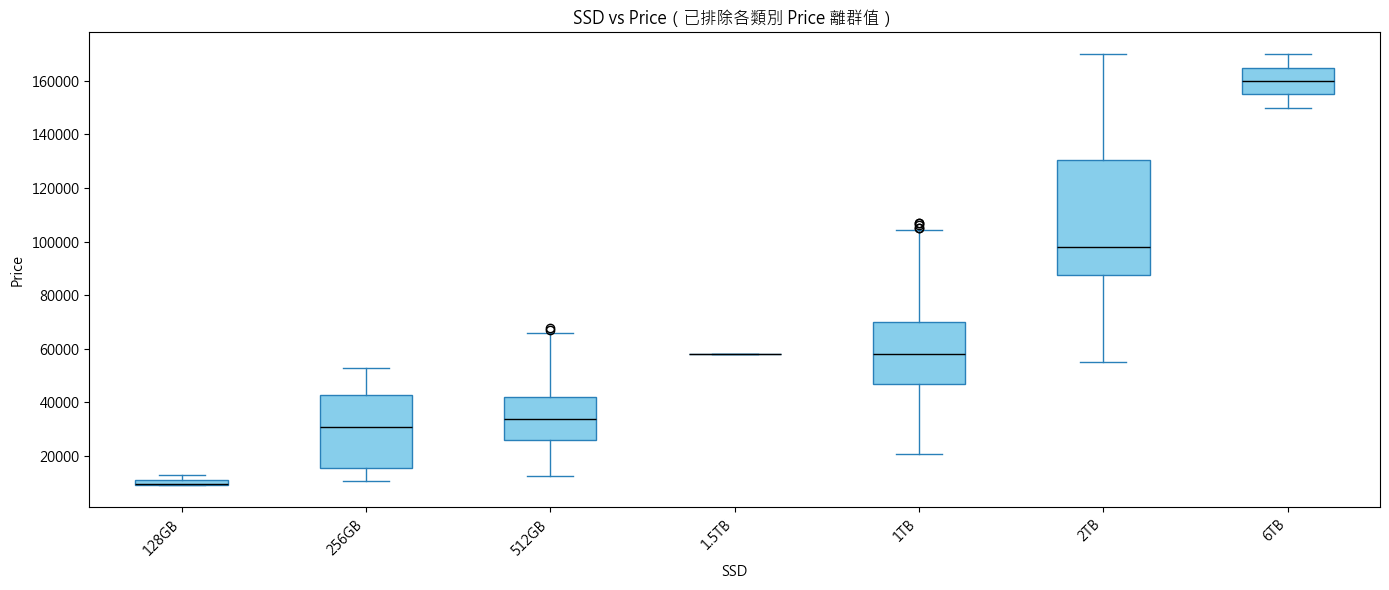

In [104]:
import matplotlib.pyplot as plt

# 1. 排除各 SSD 類別內 Price 離群值（保留 eMMC）
ssd_clean_rows = []
for val in df['SSD'].dropna().unique():
    group = df[df['SSD'] == val]
    Q1 = group['Price'].quantile(0.25)
    Q3 = group['Price'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    filtered = group[(group['Price'] >= lower) & (group['Price'] <= upper)]
    ssd_clean_rows.append(filtered)

df_ssd_plot = pd.concat(ssd_clean_rows).reset_index(drop=True)
print('繪圖資料筆數:', len(df_ssd_plot), '（排除 Price 離群值後）')

# 2. 依各類別中位數排序
ssd_order = (df_ssd_plot.groupby('SSD')['Price']
             .median().sort_values().index.tolist())

# 3. 解決中文字型遺失警告（支援標題或標籤含有中文）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  
plt.rcParams['axes.unicode_minus'] = False  

# 4. 建立畫布（這行必須在畫箱形圖之前！）
fig, ax = plt.subplots(figsize=(14, 6))
data_by_ssd = [df_ssd_plot[df_ssd_plot['SSD'] == s]['Price'].values for s in ssd_order]

# 5. 繪製箱形圖（使用 tick_labels 消除警告，開啟 patch_artist 允許填色）
box = ax.boxplot(data_by_ssd, tick_labels=ssd_order, vert=True, patch_artist=True)

# 6. 將所有箱子與元件調成藍色調
for patch in box['boxes']:
    patch.set_facecolor('skyblue')  # 箱子內部填充亮藍色
    patch.set_edgecolor('#2980b9')  # 箱子邊框深藍色

for whisker in box['whiskers']:
    whisker.set_color('#2980b9')    # 鬍鬚（上下延伸線）變藍色

for cap in box['caps']:
    cap.set_color('#2980b9')        # 頂部與底部橫線變藍色

for median in box['medians']:
    median.set_color('#000000')     # 中位數線黑色

# 7. 設定圖表標籤與防擠壓優化
ax.set_xlabel('SSD')
ax.set_ylabel('Price')
ax.set_title('SSD vs Price（已排除各類別 Price 離群值）')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part 3.4 離群值處理（IQR）

In [105]:
# ========== Part 3.5 離群值處理（IQR） ==========

print("處理前資料筆數:", df.shape[0])

# --- 廂型圖欄位：各類別內部計算 IQR，移除該類別的 Price 離群值 ---
box_cols = ["Brand", "Product_type", "TouchScreen", "OS", "CPU_brand", "Ram_type", "Resolution", "SSD", "RAM (GB)"]

outlier_idx = set()
for col in box_cols:
    for val in df[col].dropna().unique():
        group = df[df[col] == val]["Price"]
        Q1 = group.quantile(0.25)
        Q3 = group.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        idx = df[(df[col] == val) & ((df["Price"] < lower) | (df["Price"] > upper))].index
        outlier_idx.update(idx.tolist())

df = df.drop(index=list(outlier_idx)).reset_index(drop=True)
print("移除廂型圖離群值後:", df.shape[0], "筆")

# --- 散佈圖欄位：整體 IQR，移除數值離群值 ---
scatter_cols = ["PPI", "Weight(kg)", "Battery(Wh)"]

for col in scatter_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)].reset_index(drop=True)
    print(f"{col}: 移除 {before - df.shape[0]} 筆離群值")

print("\n處理後資料筆數:", df.shape[0])


處理前資料筆數: 1427
移除廂型圖離群值後: 1261 筆
PPI: 移除 28 筆離群值
Weight(kg): 移除 73 筆離群值
Battery(Wh): 移除 0 筆離群值

處理後資料筆數: 1160


## Part 4 EDA 分析

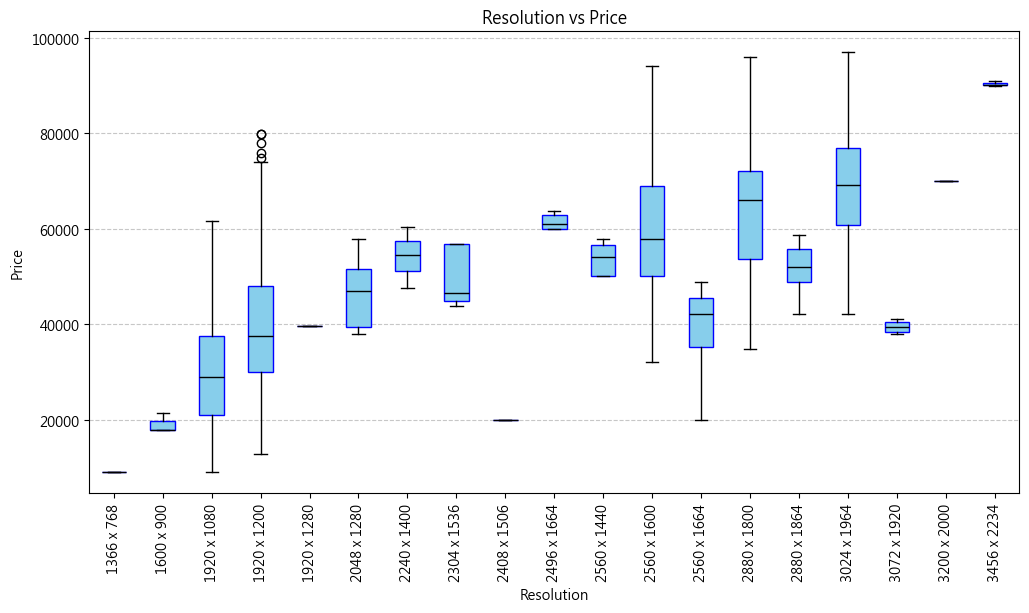

In [122]:
# Resolution vs Price 分析

import matplotlib.pyplot as plt

df_clean = df.dropna(subset=["Resolution", "Price"])

labels = sorted(df_clean["Resolution"].unique())
grouped_data = [df_clean[df_clean["Resolution"] == val]["Price"].values for val in labels]


string_labels = [str(val) for val in labels]


plt.figure(figsize=(12, 6))

plt.boxplot(grouped_data, tick_labels=string_labels, patch_artist=True,
            boxprops=dict(facecolor="skyblue", color="blue"),
            medianprops=dict(color="black"))

plt.xticks(rotation=90)
plt.xlabel("Resolution")
plt.ylabel("Price")
plt.title("Resolution vs Price") 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


SSD_GB            0.663054
PPI               0.610406
Battery(Wh)       0.558374
Core              0.445902
Warranty(year)    0.114997
Weight(kg)       -0.019676
Inch             -0.158627
Name: Price, dtype: float64


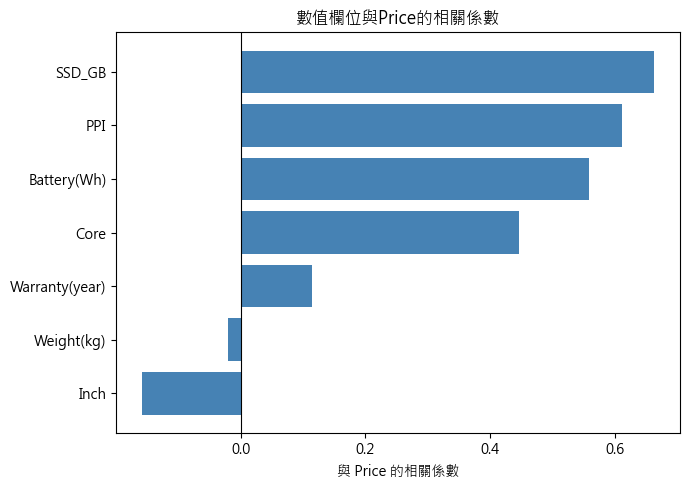

In [127]:
# 數值欄位 vs Price 的相關係數彙整表

numeric_cols = ["SSD_GB", "PPI", "Battery(Wh)", "Core", "Weight(kg)", "Inch", "Warranty(year)"]

corr_table = df[numeric_cols + ["Price"]].corr()["Price"].drop("Price").sort_values(ascending=False)
print(corr_table)

plt.figure(figsize=(7, 5))
plt.barh(corr_table.index[::-1], corr_table.values[::-1], color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("與 Price 的相關係數")
plt.title("數值欄位與Price的相關係數")
plt.tight_layout()
plt.show()


## Part 5 Feature Selection

In [129]:
features = ["Brand", "CPU_brand", "GPU",
            "Product_type", "TouchScreen", "OS", "Ram_type", "RAM (GB)",
            "Battery(Wh)", "Core", "PPI", "SSD_GB"]
y = df["Price"]

cat_cols = ["Brand", "CPU_brand", "GPU", "Product_type", "TouchScreen", "OS", "Ram_type", "RAM (GB)"]
num_cols = ["Battery(Wh)", "Core", "PPI", "SSD_GB"]

X = df[features]
print("Feature 數量:", len(features))
print("num_cols:", num_cols)
print("cat_cols:", cat_cols)


Feature 數量: 12
num_cols: ['Battery(Wh)', 'Core', 'PPI', 'SSD_GB']
cat_cols: ['Brand', 'CPU_brand', 'GPU', 'Product_type', 'TouchScreen', 'OS', 'Ram_type', 'RAM (GB)']


## Part 6 Train / Test Split (70% / 30%)

In [130]:
from sklearn.model_selection import train_test_split

num_cols_B = num_cols + ["Total_px"]

brand_dummies   = pd.get_dummies(X["Brand"],        prefix="Brand")
cpu_dummies     = pd.get_dummies(X["CPU_brand"],    prefix="CPU")
gpu_dummies     = pd.get_dummies(X["GPU"],          prefix="GPU")
ptype_dummies   = pd.get_dummies(X["Product_type"], prefix="Ptype")
touch_dummies   = pd.get_dummies(X["TouchScreen"],  prefix="Touch")
os_dummies      = pd.get_dummies(X["OS"],           prefix="OS")
ramtype_dummies = pd.get_dummies(X["Ram_type"],     prefix="RamType")
ram_dummies     = pd.get_dummies(X["RAM (GB)"],     prefix="RAM")

X_encoded = pd.concat([
    df[num_cols_B],
    brand_dummies, cpu_dummies, gpu_dummies,
    ptype_dummies, touch_dummies, os_dummies, ramtype_dummies, ram_dummies
], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3)
print("訓練集樣本數: %d，特徵數: %d" % (X_train.shape[0], X_train.shape[1]))
print("測試集樣本數: %d" % X_test.shape[0])


訓練集樣本數: 812，特徵數: 89
測試集樣本數: 348


## Part 7 資料前處理

In [131]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 812 entries, 66 to 894
Data columns (total 89 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Battery(Wh)                                  812 non-null    float64
 1   Core                                         812 non-null    int64  
 2   PPI                                          812 non-null    int64  
 3   SSD_GB                                       812 non-null    float64
 4   Total_px                                     812 non-null    int64  
 5   Brand_ASUS                                   812 non-null    bool   
 6   Brand_Acer                                   812 non-null    bool   
 7   Brand_Apple                                  812 non-null    bool   
 8   Brand_DELL                                   812 non-null    bool   
 9   Brand_Dynabook                               812 non-null    bool   
 10  Brand_

## Part 8 建模

In [132]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train, y_train)
pred_knn = model_knn.predict(X_test)

model_tree = DecisionTreeRegressor(max_depth=8)
model_tree.fit(X_train, y_train)
pred_tree = model_tree.predict(X_test)


## Part 9 模型評估

In [133]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pred_lr_train   = model_lr.predict(X_train)
pred_knn_train  = model_knn.predict(X_train)
pred_tree_train = model_tree.predict(X_train)

print("Linear Regression")
print("MSE = ", mean_squared_error(y_test, pred_lr))
print("MAE = ", mean_absolute_error(y_test, pred_lr))
print("訓練R2 = ", r2_score(y_train, pred_lr_train))
print("測試R2 = ", r2_score(y_test, pred_lr))

print('-'*30)
print("KNN Regression")
print("MSE = ", mean_squared_error(y_test, pred_knn))
print("MAE = ", mean_absolute_error(y_test, pred_knn))
print("訓練R2 = ", r2_score(y_train, pred_knn_train))
print("測試R2 = ", r2_score(y_test, pred_knn))

print('-'*30)
print("Decision Tree")
print("MSE = ", mean_squared_error(y_test, pred_tree))
print("MAE = ", mean_absolute_error(y_test, pred_tree))
print("訓練R2 = ", r2_score(y_train, pred_tree_train))
print("測試R2 = ", r2_score(y_test, pred_tree))


Linear Regression
MSE =  38080307.40980803
MAE =  4616.915754397394
訓練R2 =  0.8903353764266924
測試R2 =  0.875806642337268
------------------------------
KNN Regression
MSE =  56658009.601264365
MAE =  5622.73735632184
訓練R2 =  0.8557686492232347
測試R2 =  0.8152181815355832
------------------------------
Decision Tree
MSE =  57307982.883877724
MAE =  4952.962492377008
訓練R2 =  0.9410893651944633
測試R2 =  0.8130983886596983


## Part 10 Actual vs Predicted

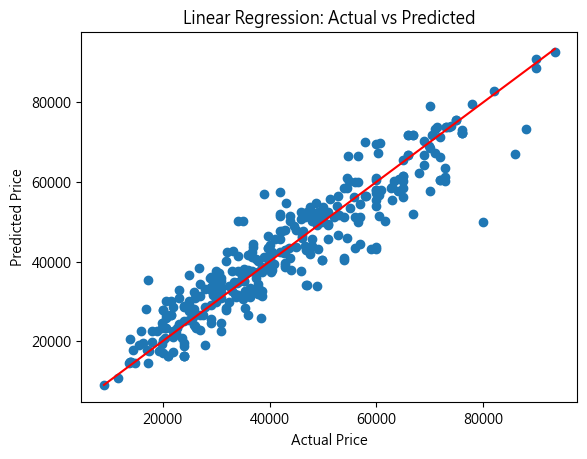

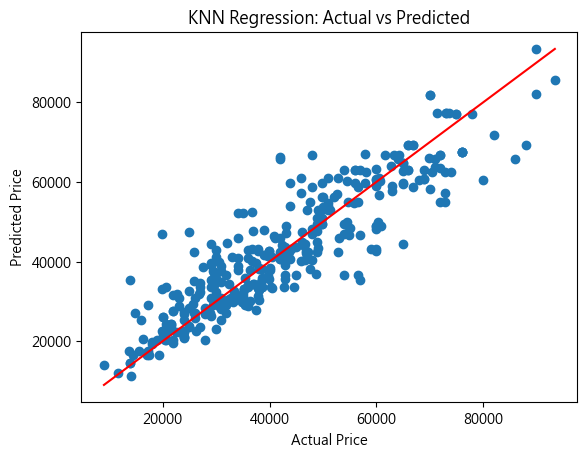

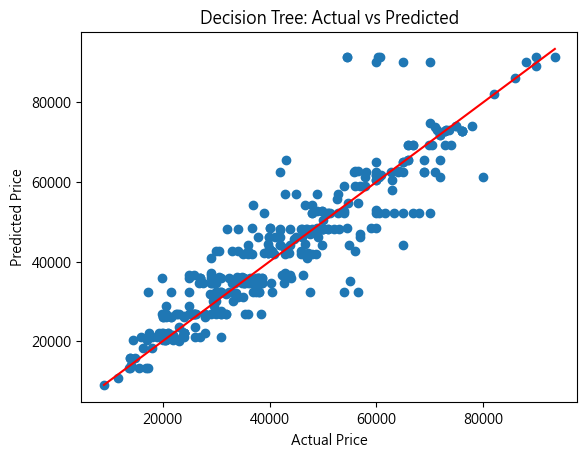

In [134]:
# Linear Regression - Actual vs Predicted
plt.scatter(y_test, pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="r")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# KNN Regression - Actual vs Predicted
plt.scatter(y_test, pred_knn)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="r")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN Regression: Actual vs Predicted")
plt.show()

# Decision Tree - Actual vs Predicted
plt.scatter(y_test, pred_tree)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="r")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()


## Part 11 殘差分析

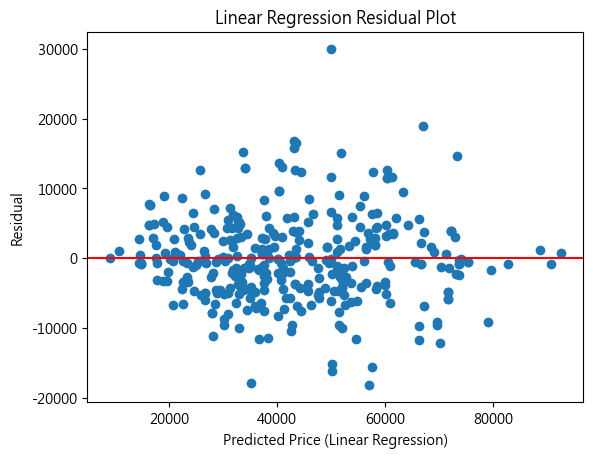

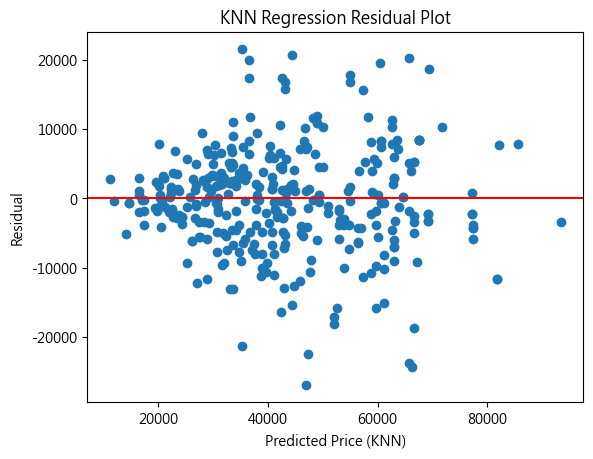

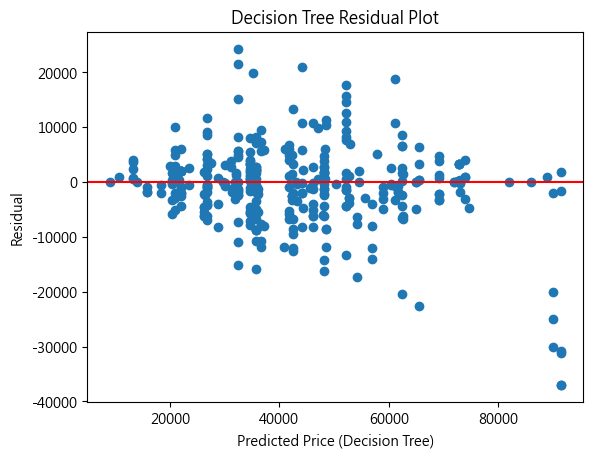

In [135]:
# Linear Regression - Residual Plot
residual_lr = y_test - pred_lr
plt.scatter(pred_lr, residual_lr)
plt.axhline(0, color="r")
plt.xlabel("Predicted Price (Linear Regression)")
plt.ylabel("Residual")
plt.title("Linear Regression Residual Plot")
plt.show()

# KNN Regression - Residual Plot
residual_knn = y_test - pred_knn
plt.scatter(pred_knn, residual_knn)
plt.axhline(0, color="r")
plt.xlabel("Predicted Price (KNN)")
plt.ylabel("Residual")
plt.title("KNN Regression Residual Plot")
plt.show()

# Decision Tree - Residual Plot
residual_tree = y_test - pred_tree
plt.scatter(pred_tree, residual_tree)
plt.axhline(0, color="r")
plt.xlabel("Predicted Price (Decision Tree)")
plt.ylabel("Residual")
plt.title("Decision Tree Residual Plot")
plt.show()
